# Gradient Descent

We'll use gradient descent (GD in the following) as an optimization algorithm to find parameter values that minimize a function.

For example, given the function $f(x)$, we'll let GD determine $\min f(x)$ by computing the "optimal" value for $x$. This optimal value will essentially be a "best guess" by gradient descent after $m$ iterations. Nevertheless, this will still only be an approximation of the true optimal parameter.

The formula for Gradient Descent is

$$
x_{n+1} = x_n - \eta\nabla f(x_n)
$$

where $x_n$ is our current best guess for the optimal $x$ value, $\eta$ is the learning rate parameter influencing the step size and $\nabla f(x)$ is the gradient at value $x$.

Hence, we compute each following update step $x_{n+1}$ using the previous value $x_n$ and stepping into the opposite direction of the gradient at value $x_n$ with a step size of $\eta$.

But what is a gradient?

The gradient is the numerical value of the slope of a function at point $x$. Hence,

$$
\nabla f(x) = \frac{df}{dx}
$$

The gradient points in the direction of the steepest increase, as the sign of the derivative tells us which direction increases the function:

$$
\frac{df}{dx} > 0
\quad\rightarrow\quad
\text{increasing } x \text{ leads to an increase in } f(x)
$$

and likewise,

$$
\frac{df}{dx} < 0
\quad\rightarrow\quad
\text{decreasing } x \text{ leads to an increase in } f(x).
$$

Therefore, since we are pursuing the minimum of the function, we always move in the opposite direction of the gradient, i.e. in the direction of the steepest decrease.


### Functions and Derivatives

For this first example, we'll use 2 functions:

$$
f(x) = x^2
$$

$$
g(x) = (x-3)^2
$$

We can directly determine their derivatives

$$
\frac{df}{dx} = 2x
$$

$$
\frac{dg}{dx} = 2(x-3)
$$

Now, there are 2 criteria as to if we can easily determine the global minima of a function analytically or if we have to approximate it using GD.

**1)** Differentiability
Differentiability for a function exists if we can calculate the derivate at any arbitrary point on the functions defined parameter space.

Mathematically, the derivate is defined as

$$
f'(x) =\lim_{h \rightarrow 0}​ \frac{f(x+h)−f(x)}{h}​
$$

If this limit exists and if finite for every point, the function is differentiable.

For instance, with $f(x)=x^2$ and $x=0$, we'd get
$$
f'(0)=\lim_{h\rightarrow0}\frac{f(0+h)-f(0)}{h}
=\lim_{h\rightarrow0}\frac{h^2}{h}
=\lim_{h\rightarrow0}h.
$$
Approaching the limit from the positive side yields
$$
\lim_{h\rightarrow0^+}h=0,
$$
whereas approaching it from the negative side yields
$$
\lim_{h\rightarrow0^-}h=0.
$$
As these two limits match, the derivative exists at $x=0$, meaning that the function is differentiable at this point.

Conversely, $f(x) = |x|$ is not differentiable at point $x = 0$, as

$$
f'(0)=\lim_{h\rightarrow0}\frac{f(0+h)-f(0)}{h}
=\lim_{h\rightarrow0}\frac{|h|}{h}
=\lim_{h\rightarrow0}1.
$$

Approaching the limit from the positive side yields
$$
\lim_{h\rightarrow0^+}h=1,
$$
whereas approaching it from the negative side yields
$$
\lim_{h\rightarrow0^-}h=-1.
$$
As these two limits don't match, the derivative doesn't exist at $x=0$, meaning that the function is not differentiable at this point.


**2)** Analytical Solveability
Next, we can calculate the optimal parameter value to find the global minimum of a function if we can easily solve the following equation

$$
\frac{df}{dx} = 0
$$

The reason for this is that, at a local minimum of a differentiable function, the derivative is equal to zero. Therefore, by setting the derivative to zero and solving the resulting equation for $x$, we can find candidate parameter values for local minima.

For some functions however, the resulting equation cannot be rearranged to obtain an exact solution for $x$. In these cases, we can use numerical optimization methods such as gradient descent to approximate the optimal parameter value.

In [160]:
def f(x: float) -> float:
    """f(x) = x^2"""
    return x**2

def g(x: float) -> float:
    """g(x) = (x - 3)^2"""
    return (x-3)**2


def df(x: float) -> float:
    """Derivate of quadratic function f: df/dx = 2x"""
    return 2*x

def dg(x: float) -> float:
    """Derivate of quadratic function g: dg/dx = 2(x-3)"""
    return 2*(x-3)

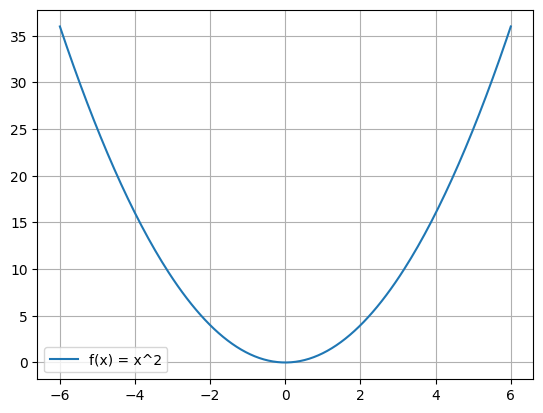

In [161]:
plot_function(f, x_max=6)

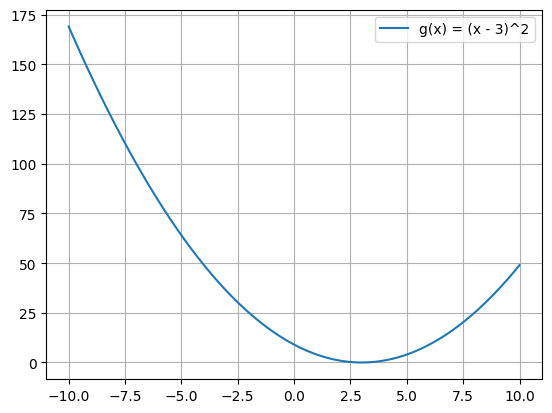

In [162]:
plot_function(g, x_max=10)

## Implementation of Gradient Descent

The following simple function implements a basic version of Gradient Descent in pure Python according to the update formula

$$
x_{n+1} = x_n - \eta \nabla f(x_n).
$$

However, we need to define a few additional variables:

`x_init` is our initial guess for the optimal parameter value $x$ that minimizes the function $f(x)$. Since the optimal value is initially unknown, we can start with an arbitrary initial guess.

`max_iter` determines the total number of update steps $m$. For instance, choosing $m=30$ results in $30$ Gradient Descent iterations and a total of $m+1=31$ $x$ values, including the initial value.


In [15]:
def gradient_descent(df: callable, x_init: float = 0, learning_rate: float = 0.01, max_iter: float = 30) -> float:
    x = x_init

    for _ in range(max_iter):
        gradient = df(x)
        x -= learning_rate * gradient
    
    return x

For our first function $f(x) = x^2$, GD approximates $\hat{x} = 0.536...$ as the optimal value $\hat{x}$ for $f(x)$ after $10$ iterations with an inital $x$ of $5$ and a learning rate of $0.1$.

In [16]:
print(gradient_descent(df, x_init=5, learning_rate=0.1, max_iter=10))

0.5368709120000001


In [18]:
def gradient_descent_history(df: callable, x_init: float = 0, learning_rate: float = 0.01, max_iter: float = 30) -> list[float]:
    x_history = [x_init]

    for _ in range(max_iter):
        gradient = df(x_history[-1])
        x_history.append(x_history[-1] - (learning_rate * gradient))
    
    return x_history

We can also save every $x_n$ and visualize them afterwards to further understand the update procedure introduced by GD.

This update stream makes sense when computing the necessary $x$ for the minimum value of $f(x)$ ourselves:

$$
\frac{df}{dx} = 0
$$

$$
2x = 0 \Longleftrightarrow\ x = 0
$$

Hence, GD will try to push the $x$ values in the direction of $\frac{df}{dx} = 0$ which is $0$.

In [164]:
x_history = gradient_descent_history(df, x_init=5, learning_rate=0.1, max_iter=10)
x_history

[5,
 4.0,
 3.2,
 2.56,
 2.048,
 1.6384,
 1.31072,
 1.0485760000000002,
 0.8388608000000002,
 0.6710886400000001,
 0.5368709120000001]

In [151]:
%run implementations.py

## Illustrative Plots

Gradient Descents behaviour is best illustrated using graphs and plots.

This simple plots visually explains the update steps of GD calculated in the previous code cell.

It becomes clear that the global minimum at $x = 0$ is not yet reached with the configured initial guess, learning rate and iterations.

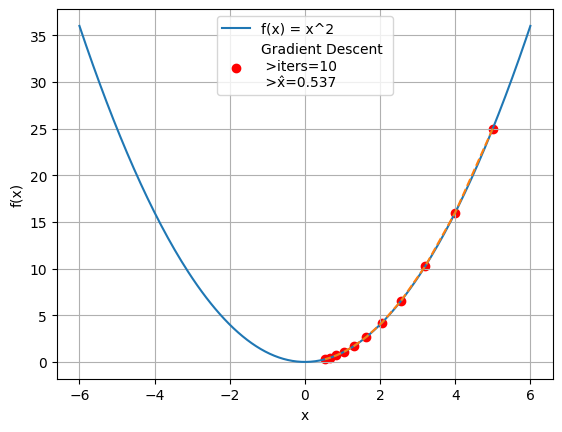

In [152]:
plot_function_and_gd(f, x_history, x_max=6)

Doubling the number of iterations from $10$ to $20$ leads to $\hat{x} = 0.058$ and we are even closer to the optimal minimum at $x=0$.

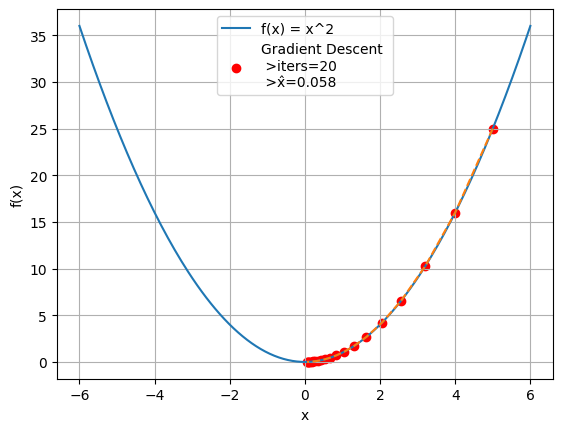

In [153]:
x_history_more_iters = gradient_descent_history(df, x_init=5, learning_rate=0.1, max_iter=20)

plot_function_and_gd(f, x_history_more_iters, x_max=6)

### Yet another example

For a different function $g(x) = (x-3)^2$, we can determine the global minimum analytically:

$$
\frac{dg}{dx} = 0
$$

$$
2(x-3) = 0 \Longleftrightarrow\ x-3 = 0 \Longleftrightarrow\ x = 3
$$

When applying Gradient Descent to this function, we expect the algorithm to converge towards $x=3$.

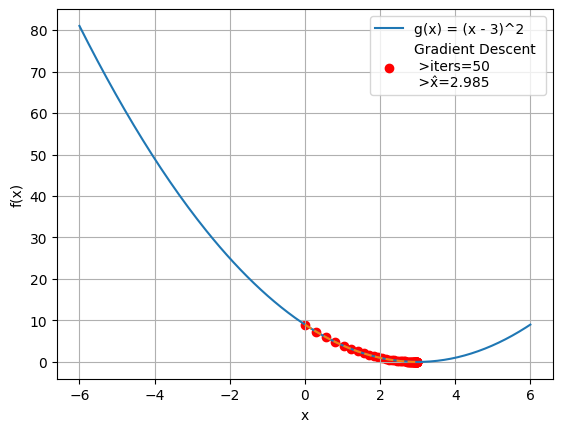

In [166]:
x_history_g = gradient_descent_history(dg, x_init=0, learning_rate=0.05, max_iter=50)

plot_function_and_gd(g, x_history_g, x_max=6)